# Projeto final

Bem vindo ao projeto final do curso/módulo de Pandas.
Neste projeto, você deve responder a um conjunto de perguntas feitas a dois conjuntos de dados:

1. [Obesity among adults by country, 1975-2016](https://www.kaggle.com/amanarora/obesity-among-adults-by-country-19752016/)
2. [GDP Per Person (1901-2011)](https://www.kaggle.com/divyansh22/gdp-per-person-19012011?select=GDP.csv)

Tais conjuntos de dados são públicos foram publicados no Kaggle. Mais instruções sobre cada um deles podem ser encontrados nos links acima. Você também os encontrará na pasta `Datasets`, dentro de nossas apostilas.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

## Perguntas - Obesity among adults by country, 1975-2016

In [2]:
path = Path.cwd().parents[2]/'data_files'/'csv'
path

PosixPath('/home/brito/projetos/treinamentos/academia-jedi/data_files/csv')

In [3]:
df_obesity = pd.read_csv(path/"obesity_cleaned.csv", index_col=0)

- Limpe os dados do DataFrame, criando uma coluna de nome 'Obesity' que conterá os valores de obesidade. Transforme em float as colunas que porventura foram importadas como string.

In [4]:
df_obesity.head()

,Country,Year,Obesity (%),Sex
0,Afghanistan,1975,0.5 [0.2-1.1],Both sexes
1,Afghanistan,1975,0.2 [0.0-0.6],Male
2,Afghanistan,1975,0.8 [0.2-2.0],Female
3,Afghanistan,1976,0.5 [0.2-1.1],Both sexes
4,Afghanistan,1976,0.2 [0.0-0.7],Male


In [5]:
df_obesity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24570 entries, 0 to 24569
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Country      24570 non-null  object
 1   Year         24570 non-null  int64 
 2   Obesity (%)  24570 non-null  object
 3   Sex          24570 non-null  object
dtypes: int64(1), object(3)
memory usage: 959.8+ KB


In [6]:
df_obesity.columns = df_obesity.columns.str.upper().str.replace(' ', '')

In [7]:
df_obesity['OBESITY(%)'].replace('[\[\]-]', ' ', regex=True).str.split()
df_obesity['OBESITY(%)'].replace('[\[\]-]', ' ', regex=True).str.split(expand=True)
df_obesity['OBESITY(%)'].replace('[\[\]-]', ' ', regex=True).str.split(expand=True)[[0,1,2]]
df_obesity[['percent', 'minor', 'major']] = df_obesity['OBESITY(%)'].replace('No data', '0 0 0').replace('[\[\]-]', ' ', regex=True).str.split(expand=True)[[0,1,2]].apply(pd.to_numeric)
# df_obesity=df_obesity.astype({'percent': 'Float64', 'minor': 'Float64', 'major': 'Float64'})
df_obesity.columns = df_obesity.columns.str.upper().str.replace(' ', '')
df_obesity.dtypes
df_obesity.info()


<class 'pandas.core.frame.DataFrame'>
Index: 24570 entries, 0 to 24569
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   COUNTRY     24570 non-null  object 
 1   YEAR        24570 non-null  int64  
 2   OBESITY(%)  24570 non-null  object 
 3   SEX         24570 non-null  object 
 4   PERCENT     24570 non-null  float64
 5   MINOR       24570 non-null  float64
 6   MAJOR       24570 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.5+ MB


- Qual o percentual médio de obesidade por sexo no mundo no ano de 2015?

In [8]:
a2015 = df_obesity.YEAR == 2015
male = df_obesity.SEX == 'Male'
feme = df_obesity.SEX == 'Female'
df_obesity[a2015].groupby('SEX')['PERCENT'].mean()

SEX
Both sexes    19.108205
Female        22.429744
Male          15.652821
Name: PERCENT, dtype: float64

- Quais são os 5 países com a maior e a menor taxa de aumento nos índices de obesidade no período observado?

In [9]:
display(df_obesity)
display('Maior taxa')
display(df_obesity.sort_values(by='PERCENT', ascending=False).COUNTRY.unique()[:5])
display('Menor taxa')
df_obesity.sort_values(by='PERCENT', ascending=True).COUNTRY.unique()[:5]

,COUNTRY,YEAR,OBESITY(%),SEX,PERCENT,MINOR,MAJOR
0,Afghanistan,1975,0.5 [0.2-1.1],Both sexes,0.5,0.2,1.1
1,Afghanistan,1975,0.2 [0.0-0.6],Male,0.2,0.0,0.6
2,Afghanistan,1975,0.8 [0.2-2.0],Female,0.8,0.2,2.0
3,Afghanistan,1976,0.5 [0.2-1.1],Both sexes,0.5,0.2,1.1
4,Afghanistan,1976,0.2 [0.0-0.7],Male,0.2,0.0,0.7
...,...,...,...,...,...,...,...
24565,Zimbabwe,2015,4.5 [2.4-7.6],Male,4.5,2.4,7.6
24566,Zimbabwe,2015,24.8 [18.9-31.3],Female,24.8,18.9,31.3
24567,Zimbabwe,2016,15.5 [12.0-19.2],Both sexes,15.5,12.0,19.2
24568,Zimbabwe,2016,4.7 [2.5-8.0],Male,4.7,2.5,8.0


'Maior taxa'

array(['Nauru', 'Cook Islands', 'Palau', 'Marshall Islands', 'Tuvalu'],
      dtype=object)

'Menor taxa'

array(['Monaco', 'South Sudan', 'San Marino', 'Sudan', 'Viet Nam'],
      dtype=object)

- Quais os países com maiores e menores níveis percetuais de obesidade em 2015?

In [10]:
df_obesity[a2015]['PERCENT'].max()
df_obesity[a2015 & (df_obesity[a2015]['PERCENT']==df_obesity[a2015]['PERCENT'].max())]


,COUNTRY,YEAR,OBESITY(%),SEX,PERCENT,MINOR,MAJOR
15116,Nauru,2015,63.1 [55.5-70.3],Female,63.1,55.5,70.3


- Qual a diferença média percentual de obesidade entre sexos ao longo dos anos para o Brasil?

,COUNTRY,OBESITY(%),SEX,PERCENT,MINOR,MAJOR
YEAR,,,,,,
1975,Brazil,5.2 [3.3-7.9],Both sexes,5.2,3.3,7.9
1975,Brazil,3.0 [1.4-5.7],Male,3.0,1.4,5.7
1975,Brazil,7.3 [4.0-12.0],Female,7.3,4.0,12.0
1976,Brazil,5.5 [3.5-8.1],Both sexes,5.5,3.5,8.1
1976,Brazil,3.2 [1.5-5.8],Male,3.2,1.5,5.8
...,...,...,...,...,...,...
2015,Brazil,18.0 [13.9-22.6],Male,18.0,13.9,22.6
2015,Brazil,24.9 [20.3-29.8],Female,24.9,20.3,29.8
2016,Brazil,22.1 [18.7-25.7],Both sexes,22.1,18.7,25.7


YEAR
1975    4.3
1976    4.4
1977    4.6
1978    4.7
1979    4.9
1980    4.9
1981    5.1
1982    5.2
1983    5.4
1984    5.5
1985    5.6
1986    5.7
1987    5.8
1988    5.9
1989    6.0
1990    6.1
1991    6.1
1992    6.3
1993    6.3
1994    6.4
1995    6.4
1996    6.5
1997    6.6
1998    6.7
1999    6.8
2000    6.8
2001    6.8
2002    6.8
2003    6.9
2004    6.9
2005    6.9
2006    6.9
2007    7.0
2008    6.9
2009    7.0
2010    7.0
2011    6.9
2012    6.9
2013    6.9
2014    6.9
2015    6.9
2016    6.9
Name: PERCENT, dtype: float64

<Axes: xlabel='YEAR'>

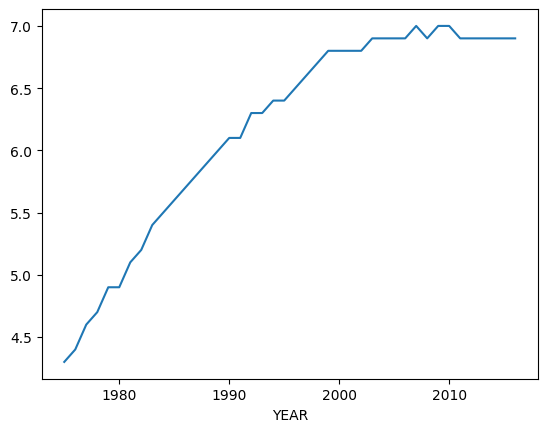

In [11]:
brasil_obesity = df_obesity[df_obesity.COUNTRY == 'Brazil'].set_index('YEAR')
display(brasil_obesity)

female=brasil_obesity.SEX == 'Female'
male=brasil_obesity.SEX == 'Male'
# display(brasil_obesity[female]['PERCENT'])
# display(brasil_obesity[male]['PERCENT'])
brasil_obesity.loc[female, 'PERCENT'].values - brasil_obesity.loc[male, 'PERCENT'].values
display(brasil_obesity.loc[female, 'PERCENT'] - brasil_obesity.loc[male, 'PERCENT'])
(brasil_obesity.loc[female, 'PERCENT'] - brasil_obesity.loc[male, 'PERCENT']).plot()

- Você conseguiria plotar um gráfico mostrando a evolução da obesidade para ambos sexos no mundo?

<Axes: xlabel='YEAR'>

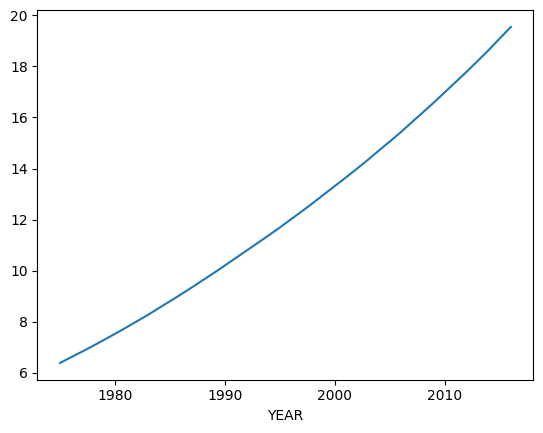

In [12]:
both = df_obesity.SEX.str.contains('both', case=False)
df_obesity.loc[both].groupby('YEAR')['PERCENT'].mean().plot()

## Perguntas - GDP Per Person (1901-2011)

In [13]:
df_gdp = pd.read_csv(path/"gdp.csv", decimal=".")
df_gdp.columns = [x.strip().upper() for x in df_gdp.columns]
display(df_gdp.info())
df_gdp

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   COUNTRY  4419 non-null   object
 1   REGION   4419 non-null   object
 2   YEAR     4419 non-null   object
 3   GDP_PP   4419 non-null   object
dtypes: object(4)
memory usage: 138.2+ KB


None

,COUNTRY,REGION,YEAR,GDP_PP
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1901,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1906,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1911,634.25
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1916,647.28
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1921,662.40
...,...,...,...,...
4414,Zimbabwe,Sub-Saharan Africa,1/1/1991,782.09
4415,Zimbabwe,Sub-Saharan Africa,1/1/1996,781.50
4416,Zimbabwe,Sub-Saharan Africa,1/1/2001,719.96
4417,Zimbabwe,Sub-Saharan Africa,1/1/2006,520.17


- Limpe o conjunto de dados, convertendo strings em datas ou float, quando necessário.

In [14]:
df_gdp.YEAR = pd.to_datetime(df_gdp.YEAR)
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   COUNTRY  4419 non-null   object        
 1   REGION   4419 non-null   object        
 2   YEAR     4419 non-null   datetime64[ns]
 3   GDP_PP   4419 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 138.2+ KB


In [15]:
df_gdp.GDP_PP=pd.to_numeric(df_gdp.GDP_PP.str.strip().str.replace(',', ''))
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   COUNTRY  4419 non-null   object        
 1   REGION   4419 non-null   object        
 2   YEAR     4419 non-null   datetime64[ns]
 3   GDP_PP   4419 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 138.2+ KB


In [16]:
df_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   COUNTRY  4419 non-null   object        
 1   REGION   4419 non-null   object        
 2   YEAR     4419 non-null   datetime64[ns]
 3   GDP_PP   4419 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 138.2+ KB


- Você conseguiria informar o primeiro valor registrado de cada país?

In [17]:
df_gdp.groupby('COUNTRY')['YEAR'].min()

COUNTRY
Afghanistan   1901-01-01
Albania       1901-01-01
Algeria       1901-01-01
Andorra       1901-01-01
Angola        1901-01-01
                 ...    
Venezuela     1901-01-01
Vietnam       1901-01-01
Yemen, Rep.   1901-01-01
Zambia        1901-01-01
Zimbabwe      1901-01-01
Name: YEAR, Length: 193, dtype: datetime64[ns]

In [18]:
df_gdp.groupby('COUNTRY')['YEAR'].min().max()

Timestamp('1991-01-01 00:00:00')

In [19]:
df_gdp.groupby('COUNTRY')['YEAR'].min().value_counts()


YEAR
1901-01-01    192
1991-01-01      1
Name: count, dtype: int64

In [20]:
df_gdp.groupby('COUNTRY')['YEAR'].min()[df_gdp.groupby('COUNTRY')['YEAR'].min()==df_gdp.groupby('COUNTRY')['YEAR'].min().max()]

COUNTRY
Kosovo   1991-01-01
Name: YEAR, dtype: datetime64[ns]

- Informe as regiões com maiores crescimentos de PIB per capita no século passado.

In [21]:
df_gdp

,COUNTRY,REGION,YEAR,GDP_PP
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901-01-01,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906-01-01,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911-01-01,634.25
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916-01-01,647.28
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921-01-01,662.40
...,...,...,...,...
4414,Zimbabwe,Sub-Saharan Africa,1991-01-01,782.09
4415,Zimbabwe,Sub-Saharan Africa,1996-01-01,781.50
4416,Zimbabwe,Sub-Saharan Africa,2001-01-01,719.96
4417,Zimbabwe,Sub-Saharan Africa,2006-01-01,520.17


In [22]:
anos = df_gdp.YEAR.dt.year.unique()
anos

array([1901, 1906, 1911, 1916, 1921, 1926, 1931, 1936, 1941, 1946, 1951,
       1956, 1961, 1966, 1971, 1976, 1981, 1986, 1991, 1996, 2001, 2006,
       2011], dtype=int32)

In [23]:
c19 = df_gdp.YEAR.dt.year < 2000
c19

0        True
1        True
2        True
3        True
4        True
        ...  
4414     True
4415     True
4416    False
4417    False
4418    False
Name: YEAR, Length: 4419, dtype: bool

In [24]:
df_gdp.loc[c19]

,COUNTRY,REGION,YEAR,GDP_PP
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901-01-01,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906-01-01,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911-01-01,634.25
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916-01-01,647.28
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921-01-01,662.40
...,...,...,...,...
4411,Zimbabwe,Sub-Saharan Africa,1976-01-01,762.17
4412,Zimbabwe,Sub-Saharan Africa,1981-01-01,790.30
4413,Zimbabwe,Sub-Saharan Africa,1986-01-01,742.30
4414,Zimbabwe,Sub-Saharan Africa,1991-01-01,782.09


In [25]:
mean_c19 = df_gdp.loc[c19].groupby(by='REGION')['GDP_PP'].mean()
mean_c19

REGION
Asia                                              3001.478630
Australia and Oceania                             4041.449000
Central America and the Caribbean                 3541.117132
Europe                                            7995.989024
Middle East, North Africa, and Greater Arabia     6432.389435
North America                                    11384.292500
South America                                     3815.537875
Sub-Saharan Africa                                1348.643826
Name: GDP_PP, dtype: float64

In [26]:
c20 = df_gdp.YEAR.dt.year >= 2000
mean_c20 = df_gdp.loc[c20].groupby(by='REGION')['GDP_PP'].mean()
mean_c20

REGION
Asia                                              9249.110741
Australia and Oceania                             8201.803953
Central America and the Caribbean                 9135.598596
Europe                                           23399.974113
Middle East, North Africa, and Greater Arabia    14136.281449
North America                                    30935.762500
South America                                     7894.965556
Sub-Saharan Africa                                2897.842609
Name: GDP_PP, dtype: float64

In [27]:
(mean_c20 - mean_c19).sort_values(ascending=False)

REGION
North America                                    19551.470000
Europe                                           15403.985090
Middle East, North Africa, and Greater Arabia     7703.892014
Asia                                              6247.632111
Central America and the Caribbean                 5594.481465
Australia and Oceania                             4160.354953
South America                                     4079.427681
Sub-Saharan Africa                                1549.198783
Name: GDP_PP, dtype: float64

In [28]:
((mean_c20 - mean_c19)/mean_c19).sort_values(ascending=False).map(lambda x: f'{x:.02%}')

REGION
Asia                                             208.15%
Europe                                           192.65%
North America                                    171.74%
Central America and the Caribbean                157.99%
Middle East, North Africa, and Greater Arabia    119.77%
Sub-Saharan Africa                               114.87%
South America                                    106.92%
Australia and Oceania                            102.94%
Name: GDP_PP, dtype: object

In [29]:
result = pd.DataFrame(
    data={
        'mean 19 century': mean_c19,
        'mean 20 century': mean_c20,
        'diff': (mean_c20 - mean_c19).sort_values(ascending=False),
        'diff%': ((mean_c20 - mean_c19)/mean_c19).sort_values(ascending=False).map(lambda x: f'{x:.02%}'),
    }
)
result.sort_values(by='diff%', ascending=False)

,mean 19 century,mean 20 century,diff,diff%
REGION,,,,
Asia,3001.478630,9249.110741,6247.632111,208.15%
Europe,7995.989024,23399.974113,15403.985090,192.65%
North America,11384.292500,30935.762500,19551.470000,171.74%
Central America and the Caribbean,3541.117132,9135.598596,5594.481465,157.99%
"Middle East, North Africa, and Greater Arabia",6432.389435,14136.281449,7703.892014,119.77%
Sub-Saharan Africa,1348.643826,2897.842609,1549.198783,114.87%
South America,3815.537875,7894.965556,4079.427681,106.92%
Australia and Oceania,4041.449000,8201.803953,4160.354953,102.94%


- Preecha os anos ausentes em cada país com uma estimativa, baseada na diferença entre o próximo registro e o anterior.

In [30]:
df_gdp

,COUNTRY,REGION,YEAR,GDP_PP
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901-01-01,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906-01-01,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911-01-01,634.25
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916-01-01,647.28
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921-01-01,662.40
...,...,...,...,...
4414,Zimbabwe,Sub-Saharan Africa,1991-01-01,782.09
4415,Zimbabwe,Sub-Saharan Africa,1996-01-01,781.50
4416,Zimbabwe,Sub-Saharan Africa,2001-01-01,719.96
4417,Zimbabwe,Sub-Saharan Africa,2006-01-01,520.17


In [31]:
df_gdp.YEAR.dt.year.max()
np.arange(10, 19)
ano_arr = np.arange(df_gdp.YEAR.dt.year.min(), df_gdp.YEAR.dt.year.max() )
ano_arr

df_all_years = pd.DataFrame(ano_arr, columns=['YEAR'])
df_all_years.index = df_all_years.YEAR
df_all_years

df_years_off = ~df_all_years.YEAR.isin(df_gdp.YEAR.dt.year)
df_years_off

YEAR
1901    False
1902     True
1903     True
1904     True
1905     True
        ...  
2006    False
2007     True
2008     True
2009     True
2010     True
Name: YEAR, Length: 110, dtype: bool

In [32]:
idx_year_off = df_years_off.index
idx_year_off

Index([1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910,
       ...
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010],
      dtype='int64', name='YEAR', length=110)

In [33]:
df_gdp.rename(columns={'YEAR': 'DATE'}, inplace=True)
df_gdp['YEAR'] = df_gdp.DATE.dt.year
df_gdp

,COUNTRY,REGION,DATE,GDP_PP,YEAR
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901-01-01,613.99,1901
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906-01-01,624.04,1906
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911-01-01,634.25,1911
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916-01-01,647.28,1916
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921-01-01,662.40,1921
...,...,...,...,...,...
4414,Zimbabwe,Sub-Saharan Africa,1991-01-01,782.09,1991
4415,Zimbabwe,Sub-Saharan Africa,1996-01-01,781.50,1996
4416,Zimbabwe,Sub-Saharan Africa,2001-01-01,719.96,2001
4417,Zimbabwe,Sub-Saharan Africa,2006-01-01,520.17,2006


In [34]:
df_gdp=df_gdp.sort_values(by=['COUNTRY', 'YEAR'])

df_gdp['DELTA_GDP'] = df_gdp.GDP_PP - df_gdp.GDP_PP.shift(1)
df_gdp['DELTA_YEAR'] = df_gdp.YEAR - df_gdp.YEAR.shift(1)
df_gdp['GDP_YEAR'] = df_gdp.DELTA_GDP / df_gdp.DELTA_YEAR
df_gdp['GDP_YEAR'] = (df_gdp.DELTA_GDP / df_gdp.DELTA_YEAR).shift(-1)

df_gdp

,COUNTRY,REGION,DATE,GDP_PP,YEAR,DELTA_GDP,DELTA_YEAR,GDP_YEAR
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901-01-01,613.99,1901,NaN,NaN,2.010
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906-01-01,624.04,1906,10.05,5.0,2.042
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911-01-01,634.25,1911,10.21,5.0,2.606
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916-01-01,647.28,1916,13.03,5.0,3.024
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921-01-01,662.40,1921,15.12,5.0,3.094
...,...,...,...,...,...,...,...,...
4414,Zimbabwe,Sub-Saharan Africa,1991-01-01,782.09,1991,39.79,5.0,-0.118
4415,Zimbabwe,Sub-Saharan Africa,1996-01-01,781.50,1996,-0.59,5.0,-12.308
4416,Zimbabwe,Sub-Saharan Africa,2001-01-01,719.96,2001,-61.54,5.0,-39.958
4417,Zimbabwe,Sub-Saharan Africa,2006-01-01,520.17,2006,-199.79,5.0,1.232


In [38]:
df_result = pd.DataFrame()

for idx, row in df_gdp.sort_values(by=['COUNTRY', 'YEAR']).iterrows():
    display(row.YEAR)
    # display(df_gdp.loc[idx + 1, 'YEAR'])
    line = row.copy()
    while line.YEAR < df_gdp.loc[idx+1, 'YEAR']-1:
        line.YEAR += 1
        line.GDP_PP += line.GDP_YEAR
        line['KIND'] = 'estimated'
        line.DATE = pd.to_datetime('2025/4/9T8:19:59.123456')
        display(line)
        df_result= pd.concat([df_result, line.to_frame().transpose().reset_index()])
    break

df_result



1901

COUNTRY                                         Afghanistan
REGION        Middle East, North Africa, and Greater Arabia
DATE                             2025-04-09 08:19:59.123456
GDP_PP                                                616.0
YEAR                                                   1902
DELTA_GDP                                               NaN
DELTA_YEAR                                              NaN
GDP_YEAR                                               2.01
KIND                                              estimated
Name: 0, dtype: object

COUNTRY                                         Afghanistan
REGION        Middle East, North Africa, and Greater Arabia
DATE                             2025-04-09 08:19:59.123456
GDP_PP                                               618.01
YEAR                                                   1903
DELTA_GDP                                               NaN
DELTA_YEAR                                              NaN
GDP_YEAR                                               2.01
KIND                                              estimated
Name: 0, dtype: object

COUNTRY                                         Afghanistan
REGION        Middle East, North Africa, and Greater Arabia
DATE                             2025-04-09 08:19:59.123456
GDP_PP                                               620.02
YEAR                                                   1904
DELTA_GDP                                               NaN
DELTA_YEAR                                              NaN
GDP_YEAR                                               2.01
KIND                                              estimated
Name: 0, dtype: object

COUNTRY                                         Afghanistan
REGION        Middle East, North Africa, and Greater Arabia
DATE                             2025-04-09 08:19:59.123456
GDP_PP                                               622.03
YEAR                                                   1905
DELTA_GDP                                               NaN
DELTA_YEAR                                              NaN
GDP_YEAR                                               2.01
KIND                                              estimated
Name: 0, dtype: object

,index,COUNTRY,REGION,DATE,GDP_PP,YEAR,DELTA_GDP,DELTA_YEAR,GDP_YEAR,KIND
0,0,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,616.0,1902,NaN,NaN,2.01,estimated
0,0,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,618.01,1903,NaN,NaN,2.01,estimated
0,0,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,620.02,1904,NaN,NaN,2.01,estimated
0,0,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,622.03,1905,NaN,NaN,2.01,estimated


In [57]:
df_result = pd.DataFrame()

for idx, row in df_gdp.sort_values(by=['COUNTRY', 'YEAR']).iterrows():
    line = row.copy()
    if line.YEAR == 2011:
        continue
    while line.YEAR < df_gdp.loc[idx+1, 'YEAR']-1:
        line.YEAR += 1
        line.GDP_PP += line.GDP_YEAR
        line['KIND'] = 'estimated'
        line.DATE = pd.to_datetime('2025/4/9T8:19:59.123456')
        df_result= pd.concat([df_result, line.to_frame().transpose()])

df_result

,COUNTRY,REGION,DATE,GDP_PP,YEAR,DELTA_GDP,DELTA_YEAR,GDP_YEAR,KIND
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,618.01,1903,NaN,NaN,2.01,estimated
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,618.01,1903,NaN,NaN,2.01,estimated
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,620.02,1904,NaN,NaN,2.01,estimated
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,622.03,1905,NaN,NaN,2.01,estimated
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,626.082,1907,10.05,5.0,2.042,estimated
...,...,...,...,...,...,...,...,...,...
4416,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,560.128,2005,-61.54,5.0,-39.958,estimated
4417,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,521.402,2007,-199.79,5.0,1.232,estimated
4417,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,522.634,2008,-199.79,5.0,1.232,estimated
4417,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,523.866,2009,-199.79,5.0,1.232,estimated


In [58]:
df_result
df_result = df_result.reset_index(drop=True)
df_result

,COUNTRY,REGION,DATE,GDP_PP,YEAR,DELTA_GDP,DELTA_YEAR,GDP_YEAR,KIND
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,618.01,1903,NaN,NaN,2.01,estimated
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,618.01,1903,NaN,NaN,2.01,estimated
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,620.02,1904,NaN,NaN,2.01,estimated
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,622.03,1905,NaN,NaN,2.01,estimated
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,626.082,1907,10.05,5.0,2.042,estimated
...,...,...,...,...,...,...,...,...,...
16899,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,560.128,2005,-61.54,5.0,-39.958,estimated
16900,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,521.402,2007,-199.79,5.0,1.232,estimated
16901,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,522.634,2008,-199.79,5.0,1.232,estimated
16902,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,523.866,2009,-199.79,5.0,1.232,estimated


In [59]:
df_result = pd.concat([df_result, df_gdp])
df_result.sort_values(by='COUNTRY YEAR'.split(), inplace=True)
df_result.reset_index(drop=True, inplace=True)
df_result

,COUNTRY,REGION,DATE,GDP_PP,YEAR,DELTA_GDP,DELTA_YEAR,GDP_YEAR,KIND
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901-01-01 00:00:00,613.99,1901,NaN,NaN,2.01,NaN
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,618.01,1903,NaN,NaN,2.01,estimated
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,618.01,1903,NaN,NaN,2.01,estimated
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,620.02,1904,NaN,NaN,2.01,estimated
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,622.03,1905,NaN,NaN,2.01,estimated
...,...,...,...,...,...,...,...,...,...
21318,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,521.402,2007,-199.79,5.0,1.232,estimated
21319,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,522.634,2008,-199.79,5.0,1.232,estimated
21320,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,523.866,2009,-199.79,5.0,1.232,estimated
21321,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,525.098,2010,-199.79,5.0,1.232,estimated


In [61]:
df_result.KIND.fillna('real', inplace=True)
df_result.index = df_result.YEAR
df_result

,COUNTRY,REGION,DATE,GDP_PP,YEAR,DELTA_GDP,DELTA_YEAR,GDP_YEAR,KIND
YEAR,,,,,,,,,
1901,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901-01-01 00:00:00,613.99,1901,NaN,NaN,2.01,real
1903,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,618.01,1903,NaN,NaN,2.01,estimated
1903,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,618.01,1903,NaN,NaN,2.01,estimated
1904,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,620.02,1904,NaN,NaN,2.01,estimated
1905,Afghanistan,"Middle East, North Africa, and Greater Arabia",2025-04-09 08:19:59.123456,622.03,1905,NaN,NaN,2.01,estimated
...,...,...,...,...,...,...,...,...,...
2007,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,521.402,2007,-199.79,5.0,1.232,estimated
2008,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,522.634,2008,-199.79,5.0,1.232,estimated
2009,Zimbabwe,Sub-Saharan Africa,2025-04-09 08:19:59.123456,523.866,2009,-199.79,5.0,1.232,estimated


<Axes: xlabel='YEAR', ylabel='GDP_PP'>

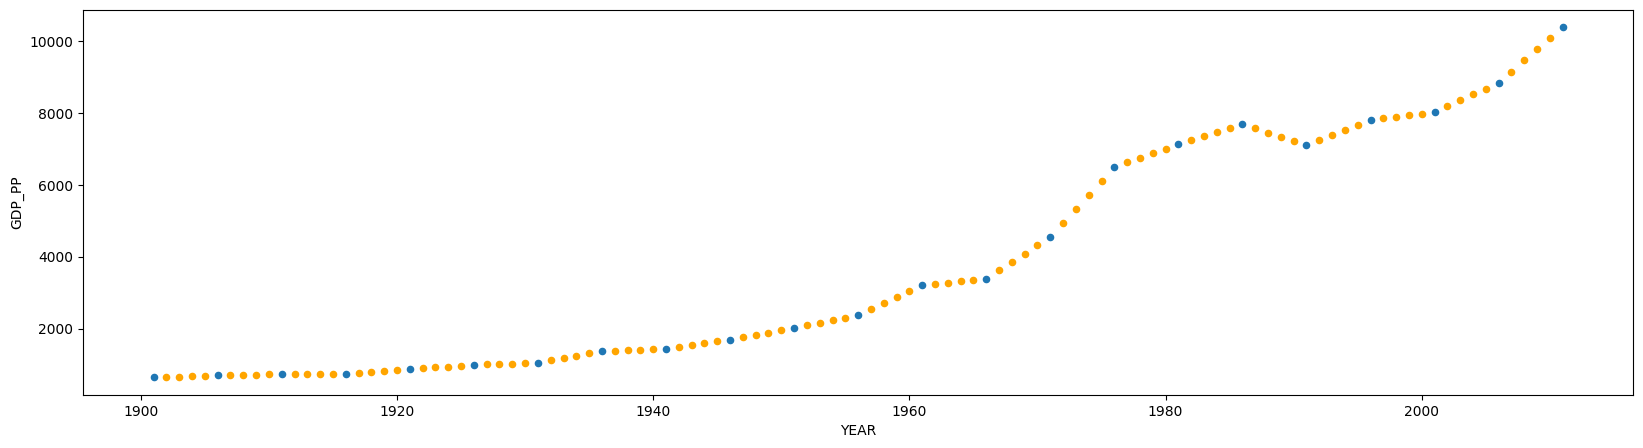

In [71]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 5))

country = 'Brazil'
df_result[(df_result.KIND == 'real') & (df_result.COUNTRY == country)].plot(kind='scatter', y='GDP_PP', x='YEAR', ax=ax)
df_result[(df_result.KIND == 'estimated') & (df_result.COUNTRY == country)].plot(kind='scatter', y='GDP_PP', x='YEAR', ax=ax, color='orange')


In [72]:
def graphit(country: str = 'Brazil') -> None:
    """Gera grafico."""
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(20, 5))

    df_result[(df_result.KIND == 'real') & (df_result.COUNTRY == country)].plot(kind='scatter', y='GDP_PP', x='YEAR', ax=ax)
    df_result[(df_result.KIND == 'estimated') & (df_result.COUNTRY == country)].plot(kind='scatter', y='GDP_PP', x='YEAR', ax=ax, color='orange')


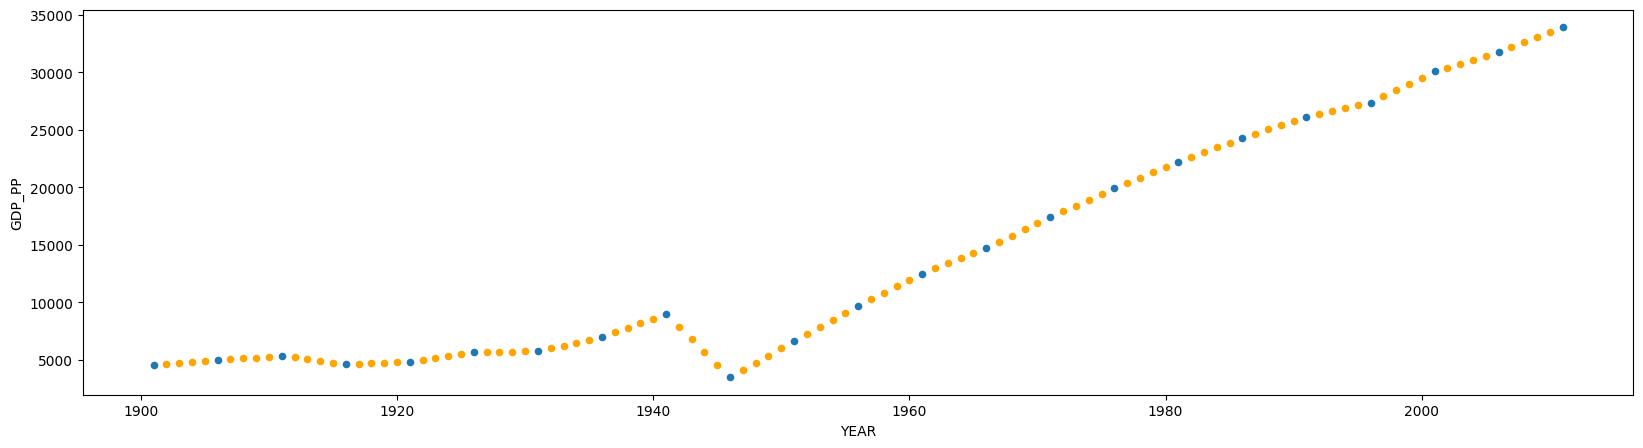

In [73]:
graphit('Germany')

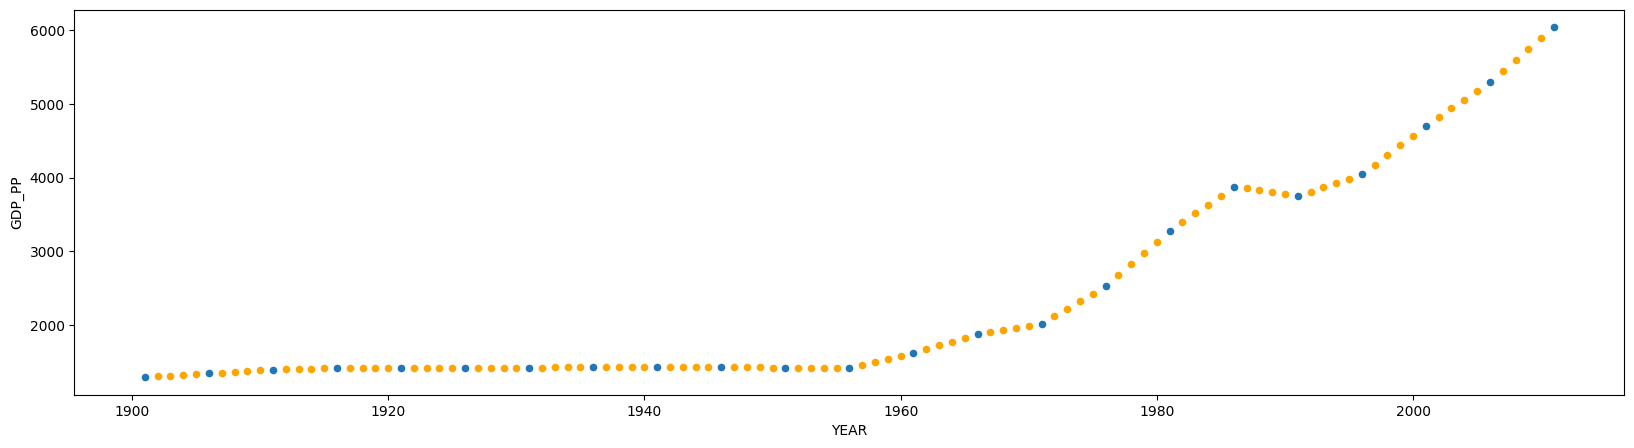

In [74]:
graphit('Egypt')

### DESAFIOS
- Você conseguiria criar um mapa do gdp ou da obesidade no mundo ao longo dos anos?

- Há uma relação entre níveis de obesidade e gdp per capita?